<a href="https://colab.research.google.com/github/tanmayrathi/ML-PRACTICAL/blob/main/ML_CS23062_9_Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tanmay Rathi Assignment 9**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML_Data/WineQT - WineQT.csv"
df=pd.read_csv(path)
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.shape

(1143, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [ ]:
df.isnull().any().any()

np.False_

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df[df.isnull().any(axis=1)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id


In [ ]:
X = df[['alcohol', 'pH']]

In [ ]:
X.head()

,alcohol,pH
0,9.4,3.51
1,9.8,3.20
2,9.8,3.26
3,9.8,3.16
4,9.4,3.51


In [ ]:
X = pd.get_dummies(X, dtype=int)

In [ ]:
X.shape

(1143, 2)

In [ ]:
X.head(5)

,alcohol,pH
0,9.4,3.51
1,9.8,3.20
2,9.8,3.26
3,9.8,3.16
4,9.4,3.51


In [ ]:
X.columns

Index(['alcohol', 'pH'], dtype='object')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

[2286.000000000005, 1411.6759493544032, 974.052743876325, 739.662828274928, 629.2491743575446, 515.679916200067, 465.8744058627457, 392.66202683909245, 367.07221911051346, 322.2431760733024]


Text(0.5, 1.0, 'Elbow Method for Optimal K')

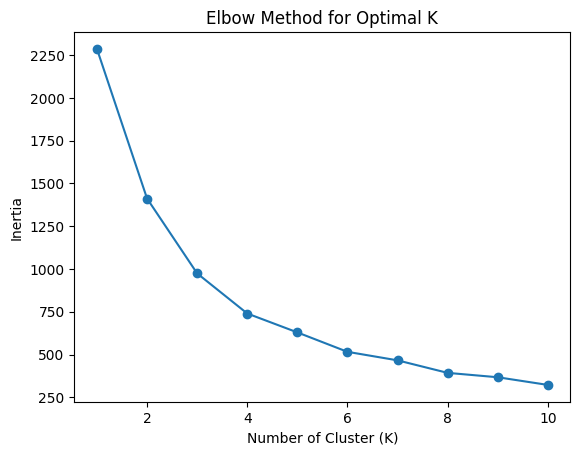

In [ ]:
inertia_values = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)

print(inertia_values)
plt.figure()
plt.plot(range(1,11), inertia_values, marker='o')
plt.xlabel("Number of Cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  Cluster  
0      9.4        5   0        4  
1      9.8      

In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 629.2491743575446
Silhouette Score: 0.3518251083201388


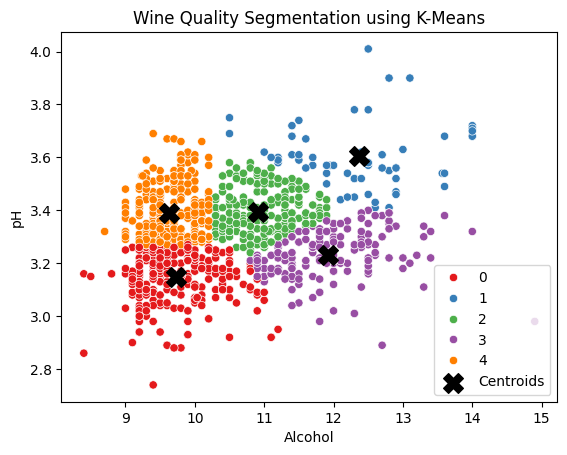

In [ ]:
plt.figure()
sns.scatterplot(x='alcohol', y='pH', hue='Cluster', data=df, palette='Set1')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,c='black', marker="X", label="Centroids"
)

plt.title("Wine Quality Segmentation using K-Means")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  Cluster  
0      9.4        5   0        2  
1      9.8      

In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 739.662828274928
Silhouette Score: 0.3718418165584869


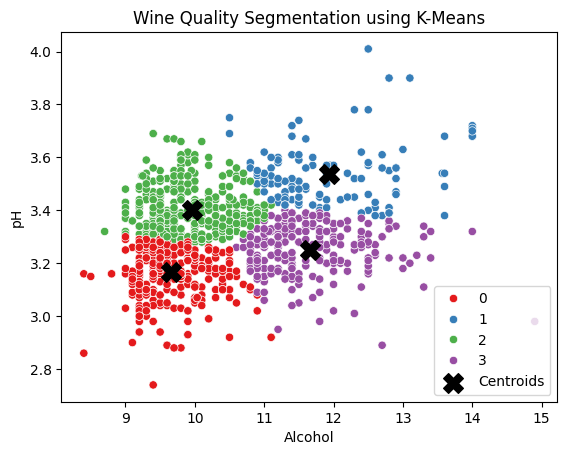

In [ ]:
plt.figure()
sns.scatterplot(x='alcohol', y='pH', hue='Cluster', data=df, palette='Set1')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,c='black', marker="X", label="Centroids"
)

plt.title("Wine Quality Segmentation using K-Means")
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.legend()
plt.show()

In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 739.662828274928
Silhouette Score: 0.3718418165584869


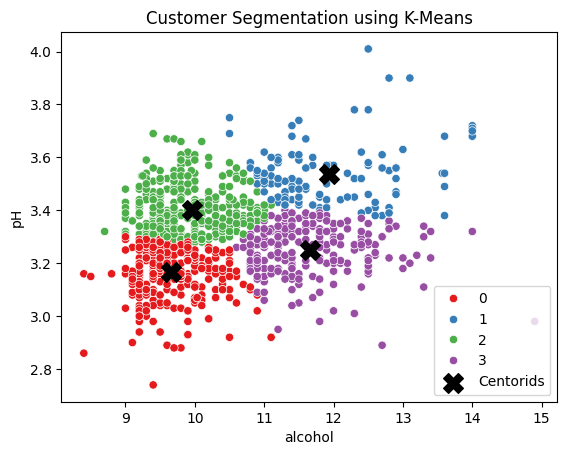

In [ ]:
plt.figure()
sns.scatterplot(x='alcohol', y='pH', hue='Cluster', data=df, palette='Set1')

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    s=200,c='black', marker="X", label="Centorids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  Cluster  
0      9.4        5   0        4  
1      9.8      

In [ ]:
print("Inertia:", kmeans.inertia_)
sil_score = silhouette_score(X_scaled, cluster)
print("Silhouette Score:",sil_score)

Inertia: 515.679916200067
Silhouette Score: 0.3478177766283331


In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
cluster = kmeans.fit_predict(X_scaled)
df['Cluster'] = cluster
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  Cluster  
0      9.4        5   0        4  
1      9.8      